In [1]:
import torch
import torch.nn as nn
import numpy as np

a=[1.,2.,3.]
print(type(a[0]))
b=torch.tensor(a)
print(b)
print(b.dtype)

<class 'float'>
tensor([1., 2., 3.])
torch.float32


In [13]:
a=np.random.normal(0,1,(2,2))
print(a)

[[ 1.11542449 -1.16198843]
 [-0.7758909   0.37688388]]


In [14]:
torch.arange(5)

tensor([0, 1, 2, 3, 4])

In [17]:
torch.range(0,5)

/tmp/ipykernel_199284/1393396694.py:1: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  torch.range(0,5)


tensor([0., 1., 2., 3., 4., 5.])

In [18]:
torch.eye(3)

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

In [21]:
a=torch.full((2, 3), 1.0)
b=torch.full_like(a,2
                  )
print(b)

tensor([[2., 2., 2.],
        [2., 2., 2.]])


In [40]:
a=torch.randn(2,3)
print(a)
b=torch.ones(3,3)
print(b)
c=torch.cat((a,b),dim=0)
d=torch.vstack((a,b))
print(c)
print(c.shape)
print(d)
print(d.shape)

tensor([[-0.9436,  0.4040, -0.9190],
        [-1.6580,  0.1738,  0.2154]])
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
tensor([[-0.9436,  0.4040, -0.9190],
        [-1.6580,  0.1738,  0.2154],
        [ 1.0000,  1.0000,  1.0000],
        [ 1.0000,  1.0000,  1.0000],
        [ 1.0000,  1.0000,  1.0000]])
torch.Size([5, 3])
tensor([[-0.9436,  0.4040, -0.9190],
        [-1.6580,  0.1738,  0.2154],
        [ 1.0000,  1.0000,  1.0000],
        [ 1.0000,  1.0000,  1.0000],
        [ 1.0000,  1.0000,  1.0000]])
torch.Size([5, 3])


In [31]:
#chunk分割
a=torch.randn(5,4)
c,d=torch.chunk(a,2,dim=0)
print(c)
print(d)
e,f=torch.chunk(a,2,dim=1)
print(e)
print(f)

tensor([[ 1.5279, -0.9024,  0.6285,  0.1108],
        [ 1.2998, -1.4810,  0.5901,  1.0572],
        [-0.9319, -0.0192, -0.8649, -0.0410]])
tensor([[-0.9274,  1.0315, -1.5659, -0.2020],
        [ 3.0805,  0.3633,  0.8575, -0.4314]])
tensor([[ 1.5279, -0.9024],
        [ 1.2998, -1.4810],
        [-0.9319, -0.0192],
        [-0.9274,  1.0315],
        [ 3.0805,  0.3633]])
tensor([[ 0.6285,  0.1108],
        [ 0.5901,  1.0572],
        [-0.8649, -0.0410],
        [-1.5659, -0.2020],
        [ 0.8575, -0.4314]])


In [44]:
a=torch.rand(3)
b=torch.rand(3)
c=torch.stack((a,b))
d=torch.stack((a,b),dim=1)#会增加维度，cat不会增加
e=torch.vstack((a,b))
print(c)
print(c.shape)
print(d)
print(d.shape)
print(e)
print(e.shape)

tensor([[0.8155, 0.1556, 0.3863],
        [0.9426, 0.4299, 0.4180]])
torch.Size([2, 3])
tensor([[0.8155, 0.9426],
        [0.1556, 0.4299],
        [0.3863, 0.4180]])
torch.Size([3, 2])
tensor([[0.8155, 0.1556, 0.3863],
        [0.9426, 0.4299, 0.4180]])
torch.Size([2, 3])


In [50]:
a=torch.rand(3,1,4,1,3)
b=torch.squeeze(a)
c=torch.squeeze(a,1)
d=torch.squeeze(a,3)
e=a.view(3,4,3)
print(b.shape)
print(c.shape)
print(d.shape)

torch.Size([3, 4, 3])
torch.Size([3, 4, 1, 3])
torch.Size([3, 1, 4, 3])


**DATASET AND DATALODER**

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

/home/nizhenhao/anaconda3/envs/cs182_hw1/lib/python3.8/site-packages/torchvision/datasets/mnist.py:498: UserWarning: The given NumPy array is not writeable, and PyTorch does not support non-writeable tensors. This means you can write to the underlying (supposedly non-writeable) NumPy array using the tensor. You may want to copy the array to protect its data or make it writeable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  /opt/conda/conda-bld/pytorch_1623448278899/work/torch/csrc/utils/tensor_numpy.cpp:180.)
  return torch.from_numpy(parsed.astype(m[2], copy=False)).view(*s)


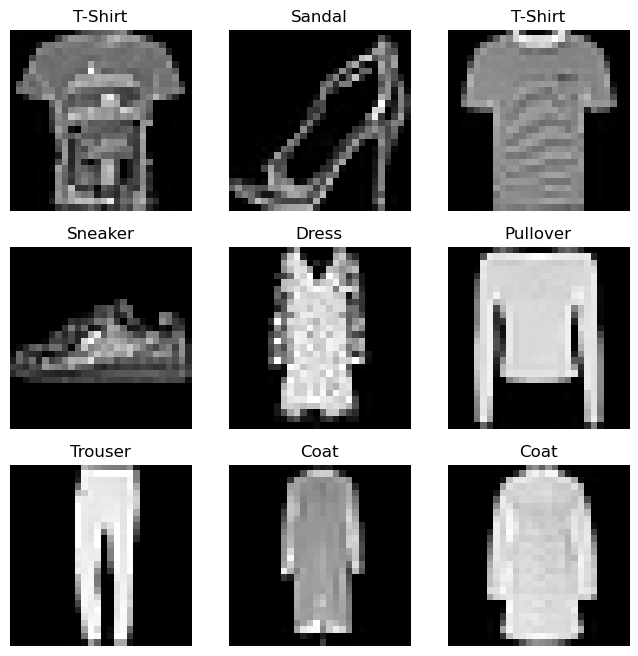

In [5]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [6]:
#构建自定义dataset 需要满足3个函数：1.init() 2.len() 3.getitem()
#init()
#getitem(index)基于index返回一个样本
#len()返回数据集的大小
#实例
import os
import pandas as pd
from torchvision.io import read_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = read_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

In [7]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [8]:
#Dataloder
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
#batch_size即是一次训练所选取的样本数，一个epoch是总样本数量，可能有多个batch.用于小批量梯度下降。shuffle=True表示在每个epoch开始时对数据进行随机打乱。
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)